In [1]:
import io
import pandas as pd
import requests

BASE_URL = "https://data-api.ecb.europa.eu/service/data"

#verified series keys from ECB SDW API (https://sdw-wsrest.ecb.europa.eu/help/)
SERIES_MAP = {
    "excess_reserves": "ILM/M.U2.C.L020100MP.U2.EUR",
    "eonia_rate": "FM/M.U2.EUR.4F.MM.EONIA.HSTA",
    "estr_rate": "EST/B.EU000A2X2A25.WT",
    "govt_yield_10y": "YC/B.U2.EUR.4F.G_N_C.SV_C_YM.PY_10Y",
    "total_deposits": "BSI/M.U2.N.A.L20.A.1.U2.0000.Z01.E",
    "total_loans": "BSI/M.U2.N.A.A20.A.1.U2.0000.Z01.E",
}

headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"}
raw_dfs = {}

#fetching the data from ECB SDW API and storing in raw_dfs dictionary
for name, key in SERIES_MAP.items():
    url = f"{BASE_URL}/{key}?format=csvdata"
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    df = pd.read_csv(io.StringIO(resp.text))
    df = df[["TIME_PERIOD", "OBS_VALUE"]].copy()
    df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
    df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"], format="mixed")
    df.set_index("TIME_PERIOD", inplace=True)
    raw_dfs[name] = df

#converting the raw dataframes to monthly frequency and storing in a master dataframe
monthly_series = {}
for name in SERIES_MAP.keys():
    monthly_series[name] = raw_dfs[name]["OBS_VALUE"].resample("MS").mean()

df_master = pd.DataFrame(monthly_series)

#forward filling missing values in the 'excess_reserves' column since the data gets published 
#with a lag and doesnt follow the classical calendar month-end convention
df_master["excess_reserves"] = df_master["excess_reserves"].ffill()

#calculating the loan-to-deposit ratio and storing it in a new column 'ltd_ratio_calc'
df_master["ltd_ratio_calc"] = (
    df_master["total_loans"] / df_master["total_deposits"]
) * 100

#creating a continuous series by adjusting EONIA and filling missing values with €STR
df_master["eonia_adjusted"] = df_master["eonia_rate"] - 0.085
df_master["short_rate"] = df_master["estr_rate"].fillna(
    df_master["eonia_adjusted"]
)

#framework A with the longer historical horizon (2004 – 2026) 
#and spliced EONIA/€STR continuous short rate
df_framework_A = df_master[
    ["excess_reserves", "short_rate", "govt_yield_10y", "ltd_ratio_calc"]
].dropna()

#framework B with the modern ESTR rate (2019-2026)
df_framework_B = df_master.loc[
    "2019-10-01":,
    ["excess_reserves", "estr_rate", "govt_yield_10y", "ltd_ratio_calc"],
].dropna()

#verifying the name and variables
print("=== FRAMEWORK A — Long Horizon (Spliced EONIA/€STR) ===")
print(
    f"Shape: {df_framework_A.shape} | "
    f"Start: {df_framework_A.index.min().strftime('%Y-%m')} | "
    f"End: {df_framework_A.index.max().strftime('%Y-%m')}"
)
print("Columns:", list(df_framework_A.columns))

print("\n=== FRAMEWORK B — Modern €STR Regime ===")
print(
    f"Shape: {df_framework_B.shape} | "
    f"Start: {df_framework_B.index.min().strftime('%Y-%m')} | "
    f"End: {df_framework_B.index.max().strftime('%Y-%m')}"
)
print("Columns:", list(df_framework_B.columns))

=== FRAMEWORK A — Long Horizon (Spliced EONIA/€STR) ===
Shape: (263, 4) | Start: 2004-09 | End: 2026-07
Columns: ['excess_reserves', 'short_rate', 'govt_yield_10y', 'ltd_ratio_calc']

=== FRAMEWORK B — Modern €STR Regime ===
Shape: (82, 4) | Start: 2019-10 | End: 2026-07
Columns: ['excess_reserves', 'estr_rate', 'govt_yield_10y', 'ltd_ratio_calc']


In [2]:
import numpy as np
from statsmodels.tsa.stattools import adfuller


def run_full_adf_suite(df, framework_name):
    print(f"\n=======================================================")
    print(f"   MODULE 2: ADF DIAGNOSTICS — {framework_name}")
    print(f"=======================================================")

    results = []

    for col in df.columns:
        #ADF test on raw values
        res_level = adfuller(df[col].dropna())
        stat_lvl, pval_lvl = res_level[0], res_level[1]
        status_lvl = (
            "Stationary I(0)" if pval_lvl < 0.05 else "Non-Stationary I(1)"
        )

        #ADF test on first differences
        df_diff = df[col].diff().dropna()
        res_diff = adfuller(df_diff)
        stat_diff, pval_diff = res_diff[0], res_diff[1]
        status_diff = "Stationary I(0)" if pval_diff < 0.05 else "Non-Stationary"

        results.append(
            {
                "Variable": col,
                "Lvl Stat": f"{stat_lvl:8.3f}",
                "Lvl p-val": f"{pval_lvl:7.4f}",
                "Lvl Status": status_lvl,
                "Diff Stat": f"{stat_diff:8.3f}",
                "Diff p-val": f"{pval_diff:7.4f}",
                "Diff Status": status_diff,
            }
        )

    res_df = pd.DataFrame(results)
    print(res_df.to_string(index=False))
    return res_df


#ADF suite on framework A (2004–2026)
adf_A = run_full_adf_suite(df_framework_A, "FRAMEWORK A (2004–2026, N=263)")

#ADF Suite on framework B (2019–2026)
adf_B = run_full_adf_suite(df_framework_B, "FRAMEWORK B (2019–2026, N=82)")


#regime correlations on framework A
#under quantitative easing (QE) and negative rates, the correlations between excess reserves, 
#short rates, government yields, and loan-to-deposit ratios may shift significantly compared 
#to pre-QE periods. This analysis helps to understand how monetary policy regimes affect 
#the relationships between key financial variables.
print("\n=======================================================")
print("   REGIME CORRELATION SHIFTS (Framework A Levels)")
print("=======================================================")

regimes = {
    "Pre-QE (2004 - 2014)": ("2004-09-01", "2014-12-01"),
    "QE / Negative Rates (2015 - 2021)": ("2015-01-01", "2021-12-01"),
    "QT / Rate Hikes (2022 - 2026)": ("2022-01-01", "2026-07-01"),
}

for r_name, (start, end) in regimes.items():
    print(f"\n--- {r_name} ---")
    corr = df_framework_A.loc[start:end].corr()
    print(corr.round(3))


   MODULE 2: ADF DIAGNOSTICS — FRAMEWORK A (2004–2026, N=263)
       Variable Lvl Stat Lvl p-val          Lvl Status Diff Stat Diff p-val     Diff Status
excess_reserves   -1.822    0.3696 Non-Stationary I(1)   -15.387     0.0000 Stationary I(0)
     short_rate   -2.264    0.1839 Non-Stationary I(1)    -3.803     0.0029 Stationary I(0)
 govt_yield_10y   -1.248    0.6528 Non-Stationary I(1)   -10.936     0.0000 Stationary I(0)
 ltd_ratio_calc   -2.228    0.1961 Non-Stationary I(1)    -2.720     0.0706  Non-Stationary

   MODULE 2: ADF DIAGNOSTICS — FRAMEWORK B (2019–2026, N=82)
       Variable Lvl Stat Lvl p-val          Lvl Status Diff Stat Diff p-val     Diff Status
excess_reserves   -1.075    0.7249 Non-Stationary I(1)    -8.469     0.0000 Stationary I(0)
      estr_rate   -1.713    0.4246 Non-Stationary I(1)    -1.950     0.3087  Non-Stationary
 govt_yield_10y   -1.188    0.6787 Non-Stationary I(1)    -3.233     0.0181 Stationary I(0)
 ltd_ratio_calc   -2.238    0.1928 Non-Stationa

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def build_liquidity_stress_index(df, window=12):
    df_idx = df.copy()

    #rolling means and standard Deviations (12-month window)
    roll_mean = df_idx.rolling(window=window).mean()
    roll_std = df_idx.rolling(window=window).std().replace(0, np.nan)

    #computing individual Z-Scores
    #inverting the excess reserves Z-score since draining reserves = higher stress score (+)
    z_reserves = -(
        (df_idx["excess_reserves"] - roll_mean["excess_reserves"])
        / roll_std["excess_reserves"]
    )

    #rates, yields, LTD: direct (spiking values = higher stress score (+))
    rate_col = "short_rate" if "short_rate" in df_idx.columns else "estr_rate"
    z_rate = (df_idx[rate_col] - roll_mean[rate_col]) / roll_std[rate_col]
    z_yield = (
        df_idx["govt_yield_10y"] - roll_mean["govt_yield_10y"]
    ) / roll_std["govt_yield_10y"]
    z_ltd = (
        df_idx["ltd_ratio_calc"] - roll_mean["ltd_ratio_calc"]
    ) / roll_std["ltd_ratio_calc"]

    #composing equal-weighted z-score
    composite_z = (z_reserves + z_rate + z_yield + z_ltd) / 4.0

    #mapping composite z-score to 0–100 stress score (using normal CDF)
    df_idx["ELSI_Score"] = norm.cdf(composite_z) * 100

    #risk classification matrix
    conditions = [
        (df_idx["ELSI_Score"] < 25),
        (df_idx["ELSI_Score"] >= 25) & (df_idx["ELSI_Score"] < 50),
        (df_idx["ELSI_Score"] >= 50) & (df_idx["ELSI_Score"] < 75),
        (df_idx["ELSI_Score"] >= 75),
    ]
    choices = [
        "🟢 Normal",
        "🟡 Friction",
        "🟠 Tightening Alert",
        "🔴 Systemic Stress",
    ]

    df_idx["Risk_Level"] = np.select(conditions, choices, default="Unknown")

    return df_idx.dropna()


#building the Eurozone Liquidity Stress Index (ELSI) for Framework A
df_elsi_A = build_liquidity_stress_index(df_framework_A)

#printing recent 10 months output
print("=== MODULE 3: EUROZONE LIQUIDITY STRESS INDEX (ELSI) OUTPUT ===")
print(df_elsi_A[["excess_reserves", "ELSI_Score", "Risk_Level"]].tail(10))

=== MODULE 3: EUROZONE LIQUIDITY STRESS INDEX (ELSI) OUTPUT ===
             excess_reserves  ELSI_Score          Risk_Level
TIME_PERIOD                                                 
2025-10-01     173135.403894   20.826953            🟢 Normal
2025-11-01     174505.261584   17.257970            🟢 Normal
2025-12-01     173060.011017   35.294978          🟡 Friction
2026-01-01     173060.011017   30.663692          🟡 Friction
2026-02-01     175536.089666   10.771269            🟢 Normal
2026-03-01     176316.233872   34.949355          🟡 Friction
2026-04-01     176316.233872   42.668844          🟡 Friction
2026-05-01     178469.961409   29.920859          🟡 Friction
2026-06-01     178523.332390   59.798671  🟠 Tightening Alert
2026-07-01     328367.063905   54.686882  🟠 Tightening Alert


In [4]:
import pandas as pd

crisis_episodes = {
    "2008 Global Financial Crisis": ("2007-07-01", "2009-06-01"),
    "2011 Euro Sovereign Debt Crisis": ("2010-12-01", "2012-12-01"),
    "2020 COVID Liquidity Shock": ("2020-01-01", "2020-08-01"),
    "2022 Rapid Rate Tightening": ("2022-06-01", "2023-05-01"),
    "2023 SVB / CS Banking Stress": ("2023-02-01", "2023-07-01"),
}

backtest_results = []

for crisis_name, (start_date, end_date) in crisis_episodes.items():
    sub_df = df_elsi_A.loc[start_date:end_date]

    if not sub_df.empty:
        max_score = sub_df["ELSI_Score"].max()
        max_date = sub_df["ELSI_Score"].idxmax().strftime("%Y-%m")
        peak_risk = sub_df.loc[sub_df["ELSI_Score"].idxmax(), "Risk_Level"]

        # First month warning trigger (Yellow or higher)
        warning_df = sub_df[sub_df["ELSI_Score"] >= 25]
        first_warning = (
            warning_df.index.min().strftime("%Y-%m")
            if not warning_df.empty
            else "No Signal"
        )

        backtest_results.append(
            {
                "Crisis Episode": crisis_name,
                "First Signal": first_warning,
                "Peak Stress Date": max_date,
                "Peak ELSI Score": f"{max_score:5.1f}",
                "Peak Risk Tier": peak_risk,
            }
        )

df_backtest = pd.DataFrame(backtest_results)

print("=======================================================")
print("   MODULE 4: HISTORICAL CRISIS BACKTESTING RESULTS")
print("=======================================================")
print(df_backtest.to_string(index=False))

   MODULE 4: HISTORICAL CRISIS BACKTESTING RESULTS
                 Crisis Episode First Signal Peak Stress Date Peak ELSI Score     Peak Risk Tier
   2008 Global Financial Crisis      2007-07          2008-07            72.2 🟠 Tightening Alert
2011 Euro Sovereign Debt Crisis      2010-12          2011-05            92.5  🔴 Systemic Stress
     2020 COVID Liquidity Shock      2020-04          2020-04            27.9         🟡 Friction
     2022 Rapid Rate Tightening      2022-06          2022-11            98.3  🔴 Systemic Stress
   2023 SVB / CS Banking Stress      2023-02          2023-02            93.7  🔴 Systemic Stress


In [5]:
import pandas as pd

# Define distinct ECB Monetary Policy Regimes across history
mp_regimes = {
    "Pre-QE Normalization / Scarcity": {
        "window": ("2004-01-01", "2014-12-01"),
        "ecb_stance": "Corridor system with scarce reserves & active rate tuning",
    },
    "Expanded APP (Quantitative Easing)": {
        "window": ("2015-03-01", "2018-12-01"),
        "ecb_stance": "Large-scale asset purchases (QE) driving excess reserves up",
    },
    "Pandemic Emergency (PEPP Bazooka)": {
        "window": ("2020-03-01", "2021-12-01"),
        "ecb_stance": "Ultra-loose expansion (€1.85T PEPP) + targeted TLTRO III",
    },
    "Historic Rate Hike Cycle": {
        "window": ("2022-07-01", "2023-09-01"),
        "ecb_stance": "Aggressive monetary tightening (+450 bps rate increases)",
    },
    "Quantitative Tightening (QT Runoff)": {
        "window": ("2023-10-01", "2026-03-01"),
        "ecb_stance": "APP reinvestment phase-out & TLTRO balance sheet shrinking",
    },
}

mp_results = []

for regime_name, info in mp_regimes.items():
    start_date, end_date = info["window"]
    sub_df = df_elsi_A.loc[start_date:end_date]

    if not sub_df.empty:
        max_score = sub_df["ELSI_Score"].max()
        avg_score = sub_df["ELSI_Score"].mean()
        
        # Check if the framework flags elevated friction (ELSI Score >= 25)
        warning_df = sub_df[sub_df["ELSI_Score"] >= 25]
        
        is_flagged = "YES" if not warning_df.empty else "NO"
        first_signal_date = (
            warning_df.index.min().strftime("%Y-%m")
            if not warning_df.empty
            else "None"
        )

        mp_results.append(
            {
                "ECB Policy Regime": regime_name,
                "Policy Description / Stance": info["ecb_stance"],
                "Flagged Friction?": is_flagged,
                "First Flag Date": first_signal_date,
                "Avg ELSI": f"{avg_score:5.1f}",
                "Max ELSI": f"{max_score:5.1f}",
            }
        )

df_mp_backtest = pd.DataFrame(mp_results)

print("===================================================================================")
print("   ELSI FRAMEWORK vs. ECB MONETARY POLICY STANCE ALIGNMENT")
print("===================================================================================")
print(df_mp_backtest.to_string(index=False))

   ELSI FRAMEWORK vs. ECB MONETARY POLICY STANCE ALIGNMENT
                  ECB Policy Regime                                 Policy Description / Stance Flagged Friction? First Flag Date Avg ELSI Max ELSI
    Pre-QE Normalization / Scarcity   Corridor system with scarce reserves & active rate tuning               YES         2005-08     43.0     92.5
 Expanded APP (Quantitative Easing) Large-scale asset purchases (QE) driving excess reserves up               YES         2015-07     36.3     65.0
  Pandemic Emergency (PEPP Bazooka)    Ultra-loose expansion (€1.85T PEPP) + targeted TLTRO III               YES         2020-04     28.6     58.3
           Historic Rate Hike Cycle    Aggressive monetary tightening (+450 bps rate increases)               YES         2022-07     89.1     98.3
Quantitative Tightening (QT Runoff)  APP reinvestment phase-out & TLTRO balance sheet shrinking               YES         2023-10     31.2     89.9


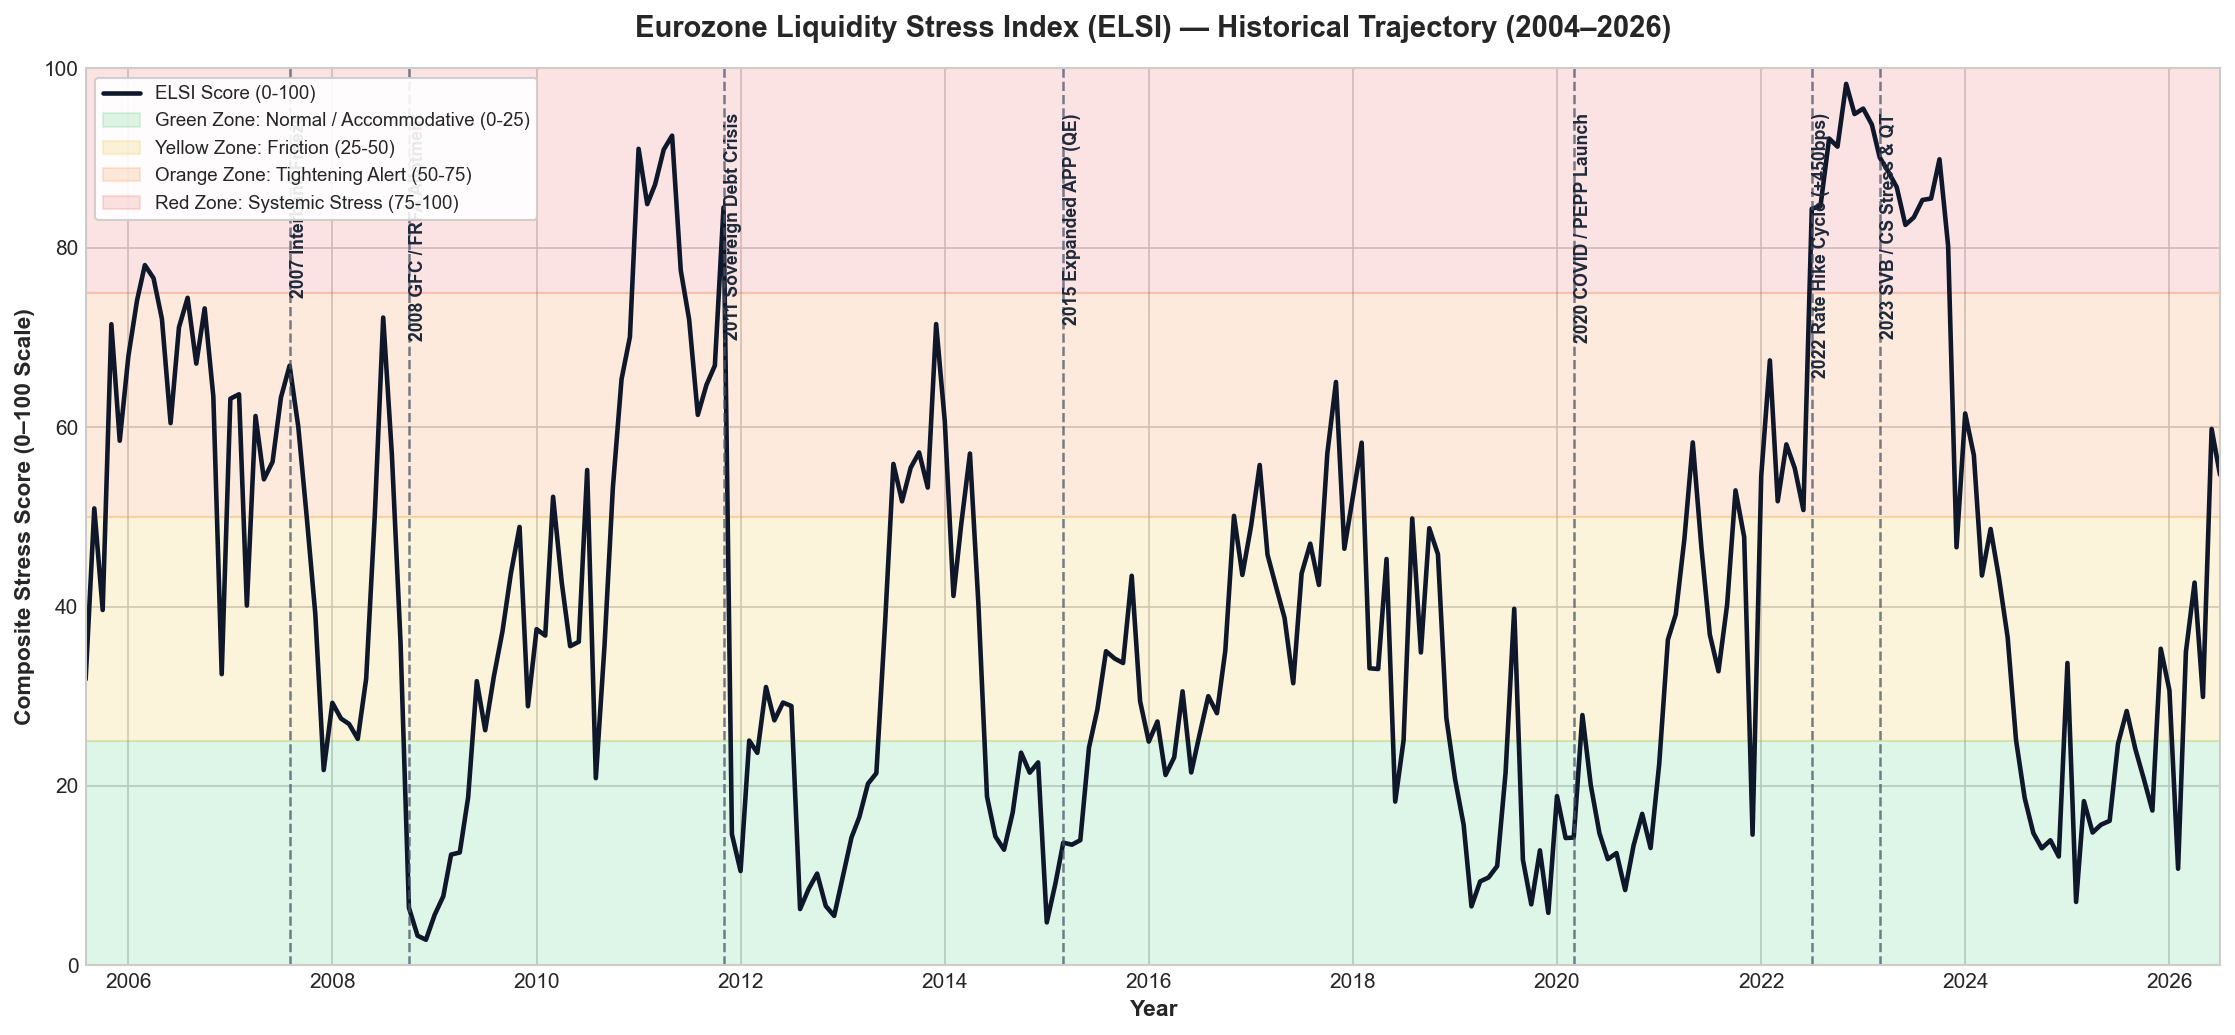

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Set clean visual style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(15, 7), dpi=150)

# 1. Plot the Main ELSI Score Line
ax.plot(
    df_elsi_A.index, 
    df_elsi_A["ELSI_Score"], 
    color="#0f172a", 
    linewidth=2.2, 
    label="ELSI Score (0-100)"
)

# 2. Add Shaded Risk Tier Backgrounds
ax.axhspan(0, 25, color="#22c55e", alpha=0.15, label="Green Zone: Normal / Accommodative (0-25)")
ax.axhspan(25, 50, color="#eab308", alpha=0.15, label="Yellow Zone: Friction (25-50)")
ax.axhspan(50, 75, color="#f97316", alpha=0.15, label="Orange Zone: Tightening Alert (50-75)")
ax.axhspan(75, 100, color="#ef4444", alpha=0.15, label="Red Zone: Systemic Stress (75-100)")

# 3. Annotate Major Historical ECB & Market Events
events = {
    "2007-08-01": "2007 Interbank Freeze",
    "2008-10-01": "2008 GFC / FRFA Allotment",
    "2011-11-01": "2011 Sovereign Debt Crisis",
    "2015-03-01": "2015 Expanded APP (QE)",
    "2020-03-01": "2020 COVID / PEPP Launch",
    "2022-07-01": "2022 Rate Hike Cycle (+450bps)",
    "2023-03-01": "2023 SVB / CS Stress & QT",
}

for date_str, event_label in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date in df_elsi_A.index or (event_date >= df_elsi_A.index.min() and event_date <= df_elsi_A.index.max()):
        ax.axvline(event_date, color="#475569", linestyle="--", alpha=0.75, linewidth=1.2)
        ax.text(
            event_date, 
            95, 
            f" {event_label}", 
            rotation=90, 
            verticalalignment="top", 
            fontsize=8.5, 
            fontweight="bold", 
            color="#1e293b"
        )

# 4. Chart Formatting & Axis Configuration
ax.set_title("Eurozone Liquidity Stress Index (ELSI) — Historical Trajectory (2004–2026)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Composite Stress Score (0–100 Scale)", fontsize=11, fontweight="bold")
ax.set_xlabel("Year", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_xlim(df_elsi_A.index.min(), df_elsi_A.index.max())

# Format X-axis to show every 2 years cleanly
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, fontsize=9)
plt.tight_layout()

# Save image directly for Slide 5 / Dashboard
plt.savefig("ELSI_Historical_Line_2004_2026.png", dpi=300)
plt.show()